# 4장 복습과제 — 4-1 분류의 개요 & 4-2 결정 트리

## **문제 1. (개념) 지도학습과 분류**

- 지도학습(Supervised Learning)이 무엇인지 한 문장으로 설명하세요.
- 분류(Classification)를 구현할 수 있는 알고리즘을 3가지 이상 적어보세요.

**답변**

- 지도학습: 학습을 위한 피처와 분류 결정값인 레이블 데이터로 모델을 학습한 뒤, 별도의 테스트 데이터 세트에서 미지의 레이블을 예측하는 방법이다.
- 분류 알고리즘 3가지: 로지스틱 회귀, KNN, 결정 트리, 서포트 벡터 머

## **문제 2. (개념) 정보 이득 vs 지니 계수**

결정 트리가 노드를 분할할 때 사용하는 두 가지 균일도 측정 방법인 **정보 이득(Information Gain)**과 **지니 계수(Gini Index)**를 각각 한 문장으로 설명하고, 사이킷런의 `DecisionTreeClassifier`가 기본으로 사용하는 것은 무엇인지 적으세요.

**답변**

- 정보 이득: 엔트로피를 기반으로 하며, 데이터를 분할했을 때 정보의 균일도가 얼마나 증가하는지를 나타내는 지수이다. 정보 이득이 높은 속성을 기준으로 분할한다.
- 지니 계수: 데이터의 균일도를 나타내는 지수로, 값이 낮을수록 데이터의 균일도가 높다. 따라서 지니 계수가 낮은 속성을 기준으로 분할한다.
- 사이킷런 기본값: 지니 계수(`criterion='gini'`)

## **문제 3. Breast Cancer 데이터 로딩 및 train/test 분리**

- sklearn 패키지의 `load_breast_cancer` 데이터셋을 이용합니다.
- 유방암 세포의 특징(반지름, 텍스처 등)을 기반으로 악성(malignant)/양성(benign)을 분류하는 이진 분류 데이터셋입니다.
- `train_test_split`을 통해 학습용 75%, 테스트용 25%로 분리하세요. (`random_state=42`)

In [21]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

## **문제 4. DecisionTreeClassifier로 모델 학습 및 정확도 평가**

- `criterion='gini'`, `max_depth=4`, `random_state=42`로 결정 트리 모델을 생성하고 학습시키세요.
- 테스트 데이터에 대한 예측을 수행하고 정확도(accuracy)를 출력하세요.

In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_clf = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    random_state=42
)
dt_clf.fit(
    X_train,
    y_train
)

pred = dt_clf.predict(X_test)
accuracy = accuracy_score(y_test, pred)

print('결정 트리 예측 정확도 : {0:.4f}'.format(accuracy))

결정 트리 예측 정확도 : 0.9510


♦️ 노드 정보 설명

- feature <= threshold : 데이터를 나누는 기준
- gini : 노드의 불순도 (0에 가까울수록 순수)
- samples : 해당 노드에 포함된 데이터 수
- value : 각 클래스별 데이터 개수
    예: [40, 5] → 첫 번째 클래스가 대부분

## **문제 5. GridSearchCV를 이용한 하이퍼파라미터 튜닝**

- `max_depth`: [3, 5, 7, 9], `min_samples_split`: [2, 4, 6] 조합으로 그리드서치를 수행하세요.
- `cv=5`로 교차검증하고, 최적 파라미터와 최고 평균 정확도를 출력하세요.
- 최적 모델(`best_estimator_`)로 테스트 데이터 정확도를 다시 평가하세요.

In [23]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [3, 5, 7, 9],
    'min_samples_split': [2, 4, 6]
}

dt = DecisionTreeClassifier(criterion='gini', random_state=42)

grid_cv = GridSearchCV(dt, param_grid=params, scoring='accuracy', cv=5)
grid_cv.fit(X_train, y_train)

print("최적 하이퍼 파라미터:", grid_cv.best_params_)
print("최고 평균 정확도:", grid_cv.best_score_)

best_dt_clf = grid_cv.best_estimator_
pred = best_dt_clf.predict(X_test)
accuracy = accuracy_score(y_test, pred)

print('최종 테스트 정확도 : {0:.4f}'.format(accuracy))

최적 하이퍼 파라미터: {'max_depth': 7, 'min_samples_split': 2}
최고 평균 정확도: 0.9365800273597811
최종 테스트 정확도 : 0.9510


## **문제 6. Feature Importance 시각화**

- 문제 5에서 얻은 최적 모델(`best_dt_clf`)에서 `feature_importances_` 속성을 추출하세요.
- 중요도 상위 10개 피처를 막대그래프(`sns.barplot`)로 시각화하세요.

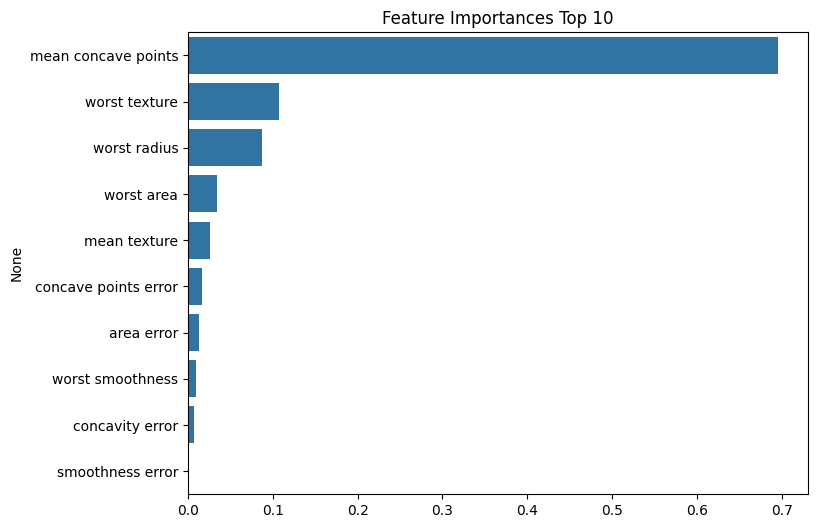

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ftr_importances_values = best_dt_clf.feature_importances_

ftr_importances = pd.Series(
    ftr_importances_values,
    index=cancer.feature_names
    )

ftr_top10 = ftr_importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))
plt.title('Feature Importances Top 10')

sns.barplot(
    x=ftr_top10.values,
    y=ftr_top10.index
    )

plt.show()

# **4-3 앙상블 학습**

# 1) 데이터셋 불러오기 및 분리
### load_breast_cancer()를 이용하여 유방암 데이터셋을 불러온 후 훈련 세트와 테스트 세트로 분리해 주세요.

* test_size = 0.25
* random_state = 113



In [25]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=113
)

# 2) 개별 분류기 학습 및 평가
### 다음 세 개의 분류기를 생성하고 각각 학습/예측한 후 정확도를 출력해 주세요.

*  Logistic Regression: solver = 'liblinear'
*  KNN: n_neighbors = 6
*  Decision Tree: max_depth=4

> #### 반복되는 학습/예측/평가 과정은 반복문을 이용하세요.

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

classifiers = [
    ('Logistic Regression', LogisticRegression(solver='liblinear')),
    ('KNN', KNeighborsClassifier(n_neighbors=6)),
    ('Decision Tree', DecisionTreeClassifier(max_depth=4, random_state=42))
]

for name, clf in classifiers:
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, pred)
    print(f'{name} 정확도: {accuracy:.4f}')

Logistic Regression 정확도: 0.9371
KNN 정확도: 0.9301
Decision Tree 정확도: 0.9091


# 3) Hard Voting과 Soft Voting
### 3-1) 2번에서 생성한 세 개의 분류기를 이용하여 Hard Voting 방식의 VotingClassifier를 생성하세요.



In [27]:
from sklearn.ensemble import VotingClassifier

log_clf = LogisticRegression(solver='liblinear')
knn_clf = KNeighborsClassifier(n_neighbors=6)
dt_clf = DecisionTreeClassifier(max_depth=4, random_state=42)

voting_clf = VotingClassifier(
    estimators=[
        ('lr', log_clf),
        ('knn', knn_clf),
        ('dt', dt_clf)
    ],
    voting='hard'
)

### 3-2) 모델을 학습한 후 테스트 데이터의 정확도(소숫점 넷째자리까지)를 출력하세요.

In [28]:
voting_clf.fit(X_train, y_train)

pred = voting_clf.predict(X_test)
accuracy = accuracy_score(y_test, pred)

print('Hard Voting 정확도: {0:.4f}'.format(accuracy))

Hard Voting 정확도: 0.9441


### 3-3) Hard Voting과 Soft Voting의 차이를 설명하세요.

**답안**

- **Hard Voting**: 여러 분류기가 예측한 결괏값 가운데 다수의 분류기가 결정한 예측값을 최종 예측값으로 선정하는 방식이다.
- **Soft Voting**: 여러 분류기가 예측한 클래스별 확률을 모두 더해 평균하고, 평균 확률이 가장 높은 레이블을 최종 예측값으로 선정하는 방식이다.
- 따라서 Hard Voting은 다수결 원칙을 사용하고, Soft Voting은 각 분류기의 예측 확률을 반영한다.

# 4) Bagging과 Pasting

### 4-1)  300개의 결정 트리가 중복을 허용하여 80개의 훈련 샘플을 추출하도록 모델을 생성하세요.
> n_jobs = -1로 설정



In [29]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=300,
    max_samples=80,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

### 4-2)  300개의 결정 트리가 중복을 허용하지 않고 80개의 훈련 샘플을 추출하도록 모델을 생성하세요.
> n_jobs = -1로 설정

In [30]:
pasting_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=300,
    max_samples=80,
    bootstrap=False,
    n_jobs=-1,
    random_state=42
)

### 4-3) 두 모델을 각각 학습하고, 예측 성능을 소숫점 넷째자리까지 평가하세요. (이때, 각 모델의 학습방식을 함께 표시하여 출력하세요.)
        출력 방식: Bagging/Pasting 정확도: 0.xxxx



In [31]:
bagging_clf.fit(X_train, y_train)
pasting_clf.fit(X_train, y_train)

bagging_pred = bagging_clf.predict(X_test)
pasting_pred = pasting_clf.predict(X_test)

bagging_accuracy = accuracy_score(y_test, bagging_pred)
pasting_accuracy = accuracy_score(y_test, pasting_pred)

print('Bagging 정확도: {0:.4f}'.format(bagging_accuracy))
print('Pasting 정확도: {0:.4f}'.format(pasting_accuracy))

Bagging 정확도: 0.9301
Pasting 정확도: 0.9301


# 5) oob 평가
### 5-1) 4번의 Bagging 모델과 동일한 조건으로 oob 평가가 가능한 모델을 생성하고 학습하세요.

In [32]:
oob_bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=300,
    max_samples=80,
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    random_state=42
)

oob_bagging_clf.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  max_samples=80, n_estimators=300, n_jobs=-1, oob_score=True,
                  random_state=42)

### 5-2) 학습된 모델의 oob 점수와 테스트 데이터셋에 대한 정확도를 각각 소수점 넷째 자리까지 출력하여 비교하세요.

In [33]:
oob_score = oob_bagging_clf.oob_score_
oob_pred = oob_bagging_clf.predict(X_test)
test_accuracy = accuracy_score(y_test, oob_pred)

print('OOB 점수: {0:.4f}'.format(oob_score))
print('테스트 정확도: {0:.4f}'.format(test_accuracy))

OOB 점수: 0.9531
테스트 정확도: 0.9301


# 랜덤 포레스트
 - '##답변 작성## 부분에 코드를 작성해주세요.
 - '##답변 작성##' 이 아닌 부분(변수명, 미리 작성된 코드)은 수정하지 마세요.


1) 사이킷런의 load_digits 데이터셋을 RandomForestClassifier을 이용해 예측하시오.

In [34]:
# 필요한 라이브러리 임포트 - 실행해주세요!
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')


digits = load_digits()
digits_data = digits.data
digits_target = digits.target


X_train, X_test, y_train, y_test = train_test_split(
    digits_data, digits_target, test_size=0.25, random_state=21
)


digits_rf = RandomForestClassifier(random_state = 10, max_depth = 7)
digits_rf.fit(X_train, y_train)
pred = digits_rf.predict(X_test)


acc = accuracy_score(y_test, pred)
print('Random Forest accuracy: {0:.4f}'.format(acc))

Random Forest accuracy: 0.9600


2) load_wine 데이터셋을 이용하여 GradientBoostingClassifier 모델을 학습하고, GridSearchCV를 활용하여 최적의 하이퍼파라미터를 찾으시오.

✅ 조건
데이터셋:
1. load_wine() 사용

2. 훈련 데이터 75% / 테스트 데이터 (25%)로 분리

3. random_state=21 사용. GridSearchCV를 이용하여 하이퍼파라미터 튜닝


4. learning_rate: [0.05, 0.1, 0.15], n_estimators: [100, 200, 300], max_depth: [2, 4, 6]

5. 최적의 하이퍼파라미터를 찾은 후 테스트 데이터로 예측

6. 테스트 데이터의 정확도를 출력할 것

✅ 참고사항
GridSearchCV는 여러 하이퍼파라미터 조합을 반복해서 학습하기 때문에 실행 시간이 다소 오래 걸릴 수 있습니다.

In [35]:
# 필요한 라이브러리 임포트
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score


wine = load_wine()
wine_data = wine.data
wine_target = wine.target


X_train, X_test, y_train, y_test = train_test_split(
    wine_data, wine_target, test_size=0.25, random_state=21
)


params = {
    'learning_rate': [0.05, 0.1, 0.15],
    'n_estimators': [100, 200, 300],
    'max_depth': [2, 4, 6]
}


gb_clf = GradientBoostingClassifier(random_state=21)
grid_cv = GridSearchCV(
    gb_clf,
    param_grid=params,
    cv=4,
    n_jobs=-1
)


grid_cv.fit(X_train, y_train)


print('최적 하이퍼파라미터:\n', grid_cv.best_params_)


y_pred = grid_cv.best_estimator_.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print('Gradient Boosting 예측 정확도: {0:.4f}'.format(accuracy))

최적 하이퍼파라미터:
 {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100}
Gradient Boosting 예측 정확도: 0.9333


# 서포트 벡터 머신(SVM)
 3) 가우시안 RBF 커널을 사용하여 gamma 값이 2이고, 하이퍼파라미터 C의 값이 0.001인 SVM 분류기를 만드시오.

 - '##답변 작성## 부분에 코드를 작성해주세요.
 - '##답변 작성##' 이 아닌 부분(변수명, 미리 작성된 코드)은 수정하지 마세요.

In [36]:
# 필요한 라이브러리 임포트
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVC
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=200, noise=0.25)

rbf_kernel_svm_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', gamma=2, C=0.001))
])

rbf_kernel_svm_clf.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()), ('svc', SVC(C=0.001, gamma=2))])